## Análisis de accidentes - Buses

### Area metropolitana del Valle de Aburrá

Manuela Cordoba

Alejandro Fernandez

Ana María Jaramillo


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pycaret.classification import *
from sklearn.model_selection import train_test_split
from imblearn.combine import *
import config

In [2]:
dataset_for_spatial_analysis = pd.read_csv(config.DATASET_WITH_SPATIAL_INFO)

#! Changing the class "material_damage_only" for "damage_only" in the column severity,
#! for being considered as 0 in the model and read the metrics straightforward
dataset_for_spatial_analysis["severity"] = dataset_for_spatial_analysis[
    "severity"
].replace("material_damage_only", "damage_only")

In [3]:
dataset_for_spatial_analysis.columns

Index(['geoco_type', 'severity', 'month', 'day', 'area_code',
       'user_category_code', 'subcategory', 'hierarchy', 'road_class',
       'stratum', 'accident_type', 'vehicle_class', 'service_type', 'brand',
       'model', 'zone', 'design', 'driver_age', 'gender', 'weekday', 'hour',
       'GiZScore_Count', 'GiPValue_Count', 'GiZScore_Severity',
       'GiPValue_Severity', 'NNeighbors_Severity', 'LMiIndex_Anselin_Count',
       'LMiZScore_Anselin_Count', 'LMiPValue_Anselin_Count',
       'COType_Anselin_Count', 'NNeighbors_Anselin_Count',
       'SpatialLag_Anselin_Count', 'LMiIndex_Anselin_Sev',
       'LMiZScore_Anselin_Sev', 'COType_Anselin_Sev',
       'ZTransform_Anselin_Sev'],
      dtype='object')

In [4]:
# List of columns to remove
columns_from_spatial_analysis = [
    "GiZScore_Count",
    "GiPValue_Count",
    "GiZScore_Severity",
    "GiPValue_Severity",
    "NNeighbors_Severity",
    "LMiIndex_Anselin_Count",
    "LMiZScore_Anselin_Count",
    "LMiPValue_Anselin_Count",
    "COType_Anselin_Count",
    "NNeighbors_Anselin_Count",
    "SpatialLag_Anselin_Count",
    "LMiIndex_Anselin_Sev",
    "LMiZScore_Anselin_Sev",
    "COType_Anselin_Sev",
    "ZTransform_Anselin_Sev",
]

# Drop the columns from the dataset
dataset_without_spatial_analysis = dataset_for_spatial_analysis.drop(
    columns=columns_from_spatial_analysis
)

In [5]:
dataset_without_spatial_analysis.columns

Index(['geoco_type', 'severity', 'month', 'day', 'area_code',
       'user_category_code', 'subcategory', 'hierarchy', 'road_class',
       'stratum', 'accident_type', 'vehicle_class', 'service_type', 'brand',
       'model', 'zone', 'design', 'driver_age', 'gender', 'weekday', 'hour'],
      dtype='object')

In [6]:
columns_list = [
    col for col in dataset_without_spatial_analysis.columns if col != "severity"
]

# Separate numeric and string columns
numeric_columns = []
string_columns = []

# Check if each column is numeric or contains strings
for col in columns_list:
    if (
        pd.to_numeric(dataset_without_spatial_analysis[col], errors="coerce")
        .notnull()
        .all()
    ):
        numeric_columns.append(col)
    else:
        string_columns.append(col)

# Print numeric and string columns
print("Numeric Columns:", numeric_columns)
print("String Columns:", string_columns)

Numeric Columns: ['month', 'day', 'user_category_code', 'hierarchy', 'road_class', 'stratum', 'model', 'driver_age', 'hour']
String Columns: ['geoco_type', 'area_code', 'subcategory', 'accident_type', 'vehicle_class', 'service_type', 'brand', 'zone', 'design', 'gender', 'weekday']


In [7]:
# Remove 'month' and 'day' from the numeric columns list
numeric_columns.remove("month")
numeric_columns.remove("day")

# Add 'month' and 'day' to the string columns list
string_columns.extend(["month", "day"])

# Print numeric and string columns
print("Numeric Columns:", numeric_columns)
print("String Columns:", string_columns)

Numeric Columns: ['user_category_code', 'hierarchy', 'road_class', 'stratum', 'model', 'driver_age', 'hour']
String Columns: ['geoco_type', 'area_code', 'subcategory', 'accident_type', 'vehicle_class', 'service_type', 'brand', 'zone', 'design', 'gender', 'weekday', 'month', 'day']


In [8]:
# Get unique values in the 'severity' column
dataset_without_spatial_analysis["severity"].unique()

array(['injured', 'damage_only', 'fatality'], dtype=object)

In [9]:
# Replace 'fatality' with 'injured'
dataset_without_spatial_analysis["severity"] = dataset_without_spatial_analysis[
    "severity"
].replace("fatality", "injured")

# Verify the changes by checking unique values again
unique_values_after = dataset_without_spatial_analysis["severity"].unique()
print("Unique values after replacement:", unique_values_after)

Unique values after replacement: ['injured' 'damage_only']


In [10]:
dataset_without_spatial_analysis["severity"].value_counts(normalize=True)

severity
damage_only    0.752566
injured        0.247434
Name: proportion, dtype: float64

In [11]:
dataset_without_spatial_analysis.head()

,geoco_type,severity,month,day,area_code,user_category_code,subcategory,hierarchy,road_class,stratum,...,vehicle_class,service_type,brand,model,zone,design,driver_age,gender,weekday,hour
0,road_network,injured,2,25,high_mix_use_areas_and_corridors,3,centralities_with_economic_predominance,3.0,6.0,0,...,bus,public,modasa,2011,comuna_3,roundabout,45,male,thursday,14
1,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,automobile,private,mazda,2011,comuna_7,road_segment,30,male,thursday,18
2,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,bus,public,agrale,2008,comuna_7,road_segment,58,male,thursday,18
3,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,automobile,private,renault,2017,comuna_7,road_segment,55,male,wednesday,19
4,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,bus,public,chevrolet,2015,comuna_7,road_segment,30,male,wednesday,19


Feature engineering.

Here, we can do some transformations to some features. For example:

- `is_weekend`: a new feature that indicates if the accident happened on a weekend.
- `is_night`: a new feature that indicates if the accident happened at night.
- `is_peak_time`: a new feature that indicates if the accident happened during peak hours. For this feature, I considered peak_time as the following hours:
  - Morning peak: 6:00 a.m. to 9:00 a.m.
  - Afternoon peak: 5:00 p.m. to 8:00 p.m.

Other possible features could be:

- `rainy_month`: a new feature that indicates if the accident happened in a month with high rainfall. For this, we can use the average rainfall for each month in Medellín. We can consider the months with higher rainfall as the rainy months: april, may, june, october, november, and december.


In [12]:
#  Changing day for "is_weekend" and hour by "is_night", and also creating "is_peak_time" (peak_time is considered if the hour is between 6 and 9, and if the hour is between 17 and 20)

dataset_without_spatial_analysis["is_weekend"] = dataset_without_spatial_analysis[
    "weekday"
].apply(lambda x: 1 if x in ["Saturday", "Sunday"] else 0)
dataset_without_spatial_analysis["is_night"] = dataset_without_spatial_analysis[
    "hour"
].apply(lambda x: 1 if x in range(0, 6) or x in range(21, 24) else 0)
dataset_without_spatial_analysis["is_peak_time"] = dataset_without_spatial_analysis[
    "hour"
].apply(lambda x: 1 if x in range(6, 10) or x in range(17, 21) else 0)

In [13]:
dataset_without_spatial_analysis.head()

,geoco_type,severity,month,day,area_code,user_category_code,subcategory,hierarchy,road_class,stratum,...,model,zone,design,driver_age,gender,weekday,hour,is_weekend,is_night,is_peak_time
0,road_network,injured,2,25,high_mix_use_areas_and_corridors,3,centralities_with_economic_predominance,3.0,6.0,0,...,2011,comuna_3,roundabout,45,male,thursday,14,0,0,0
1,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,2011,comuna_7,road_segment,30,male,thursday,18,0,0,1
2,road_network,damage_only,1,14,medium_mix_use_areas_and_corridors,2,transition_zones_centralities_endowment_areas_...,4.0,1.0,3,...,2008,comuna_7,road_segment,58,male,thursday,18,0,0,1
3,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,2017,comuna_7,road_segment,55,male,wednesday,19,0,0,1
4,road_network,damage_only,1,13,high_mix_use_areas_and_corridors,3,economically_transforming_areas,3.0,6.0,0,...,2015,comuna_7,road_segment,30,male,wednesday,19,0,0,1


In [14]:
# Setup the model with manual data type specification
exp2 = setup(
    data=dataset_without_spatial_analysis,
    target="severity",
    ignore_features=[
        "weekday",
        "hour",
    ],  # ignore weekday and hour as they are already transformed
    fix_imbalance=True,
    session_id=2023,
    normalize=True,
    data_split_stratify=True,
    fold_strategy="stratifiedkfold",
    numeric_features=[col for col in numeric_columns if col != "hour"],
    categorical_features=[col for col in string_columns if col != "weekday"],
)  # ,
# ignore_features=['clase_acci'],
# normalize_method="zscore",
# transformation=True)

,Description,Value
0,Session id,2023
1,Target,severity
2,Target type,Binary
3,Target mapping,"damage_only: 0, injured: 1"
4,Original data shape,"(79112, 24)"
5,Transformed data shape,"(107086, 99)"
6,Transformed train set shape,"(83352, 99)"
7,Transformed test set shape,"(23734, 99)"
8,Ignore features,2
9,Numeric features,6


In [15]:
train_model = compare_models(sort="Precision")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8555,0.8437,0.8555,0.8507,0.8455,0.5659,0.5822,346.9890
gbc,Gradient Boosting Classifier,0.8545,0.8323,0.8545,0.8494,0.8446,0.5636,0.5794,38.1600
rf,Random Forest Classifier,0.8536,0.8339,0.8536,0.8484,0.8436,0.5607,0.5765,6.6630
svm,SVM - Linear Kernel,0.8520,0.8018,0.8520,0.8461,0.8430,0.5605,0.5734,5.5000
ada,Ada Boost Classifier,0.8514,0.8223,0.8514,0.8454,0.8421,0.5576,0.5711,12.6440
et,Extra Trees Classifier,0.8443,0.8253,0.8443,0.8369,0.8355,0.5405,0.5512,3.5450
nb,Naive Bayes,0.8386,0.7990,0.8386,0.8320,0.8248,0.5049,0.5265,3.8790
ridge,Ridge Classifier,0.8344,0.8238,0.8344,0.8282,0.8301,0.5336,0.5362,4.0800
lda,Linear Discriminant Analysis,0.8344,0.8238,0.8344,0.8282,0.8301,0.5336,0.5362,1.1650
lr,Logistic Regression,0.8249,0.8251,0.8249,0.8214,0.8229,0.5194,0.5200,5.9630


In [ ]:
1 / 0

In [ ]:
train_model = compare_models(sort="Precision")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8558,0.8509,0.8558,0.8514,0.8453,0.5649,0.5827,1.2740
rf,Random Forest Classifier,0.8558,0.8440,0.8558,0.8510,0.8458,0.5668,0.5831,2.7670
gbc,Gradient Boosting Classifier,0.8537,0.8407,0.8537,0.8483,0.8438,0.5613,0.5768,5.3060
et,Extra Trees Classifier,0.8521,0.8358,0.8521,0.8462,0.8427,0.5592,0.5729,4.0890
ada,Ada Boost Classifier,0.8518,0.8334,0.8518,0.8459,0.8422,0.5577,0.5717,1.9460
svm,SVM - Linear Kernel,0.8502,0.8162,0.8502,0.8439,0.8417,0.5577,0.5692,1.0940
ridge,Ridge Classifier,0.8411,0.8386,0.8411,0.8350,0.8365,0.5507,0.5538,0.7230
lda,Linear Discriminant Analysis,0.8411,0.8386,0.8411,0.8350,0.8365,0.5507,0.5538,1.1060
lr,Logistic Regression,0.8344,0.8391,0.8344,0.8302,0.8318,0.5419,0.5430,1.4280
nb,Naive Bayes,0.7437,0.8063,0.7437,0.7978,0.7483,0.4115,0.4313,0.6770


In [13]:
best = create_model("lightgbm")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8528,0.8495,0.8528,0.8476,0.8425,0.5574,0.5740
1,0.8579,0.8514,0.8579,0.8536,0.8479,0.5726,0.5896
2,0.8619,0.8605,0.8619,0.8577,0.8530,0.5877,0.6025
3,0.8564,0.8573,0.8564,0.8520,0.8462,0.5673,0.5847
4,0.8583,0.8528,0.8583,0.8541,0.8482,0.5732,0.5904
5,0.8483,0.8425,0.8483,0.8428,0.8367,0.5399,0.5586
6,0.8492,0.8480,0.8492,0.8442,0.8373,0.5413,0.5610
7,0.8602,0.8509,0.8602,0.8570,0.8498,0.5770,0.5961
8,0.8564,0.8483,0.8564,0.8523,0.8458,0.5659,0.5843


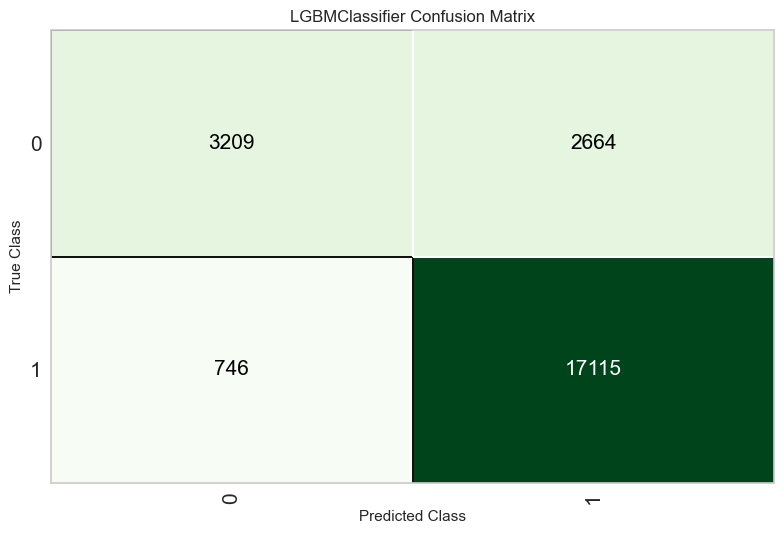

In [14]:
plot_model(best, plot="confusion_matrix")

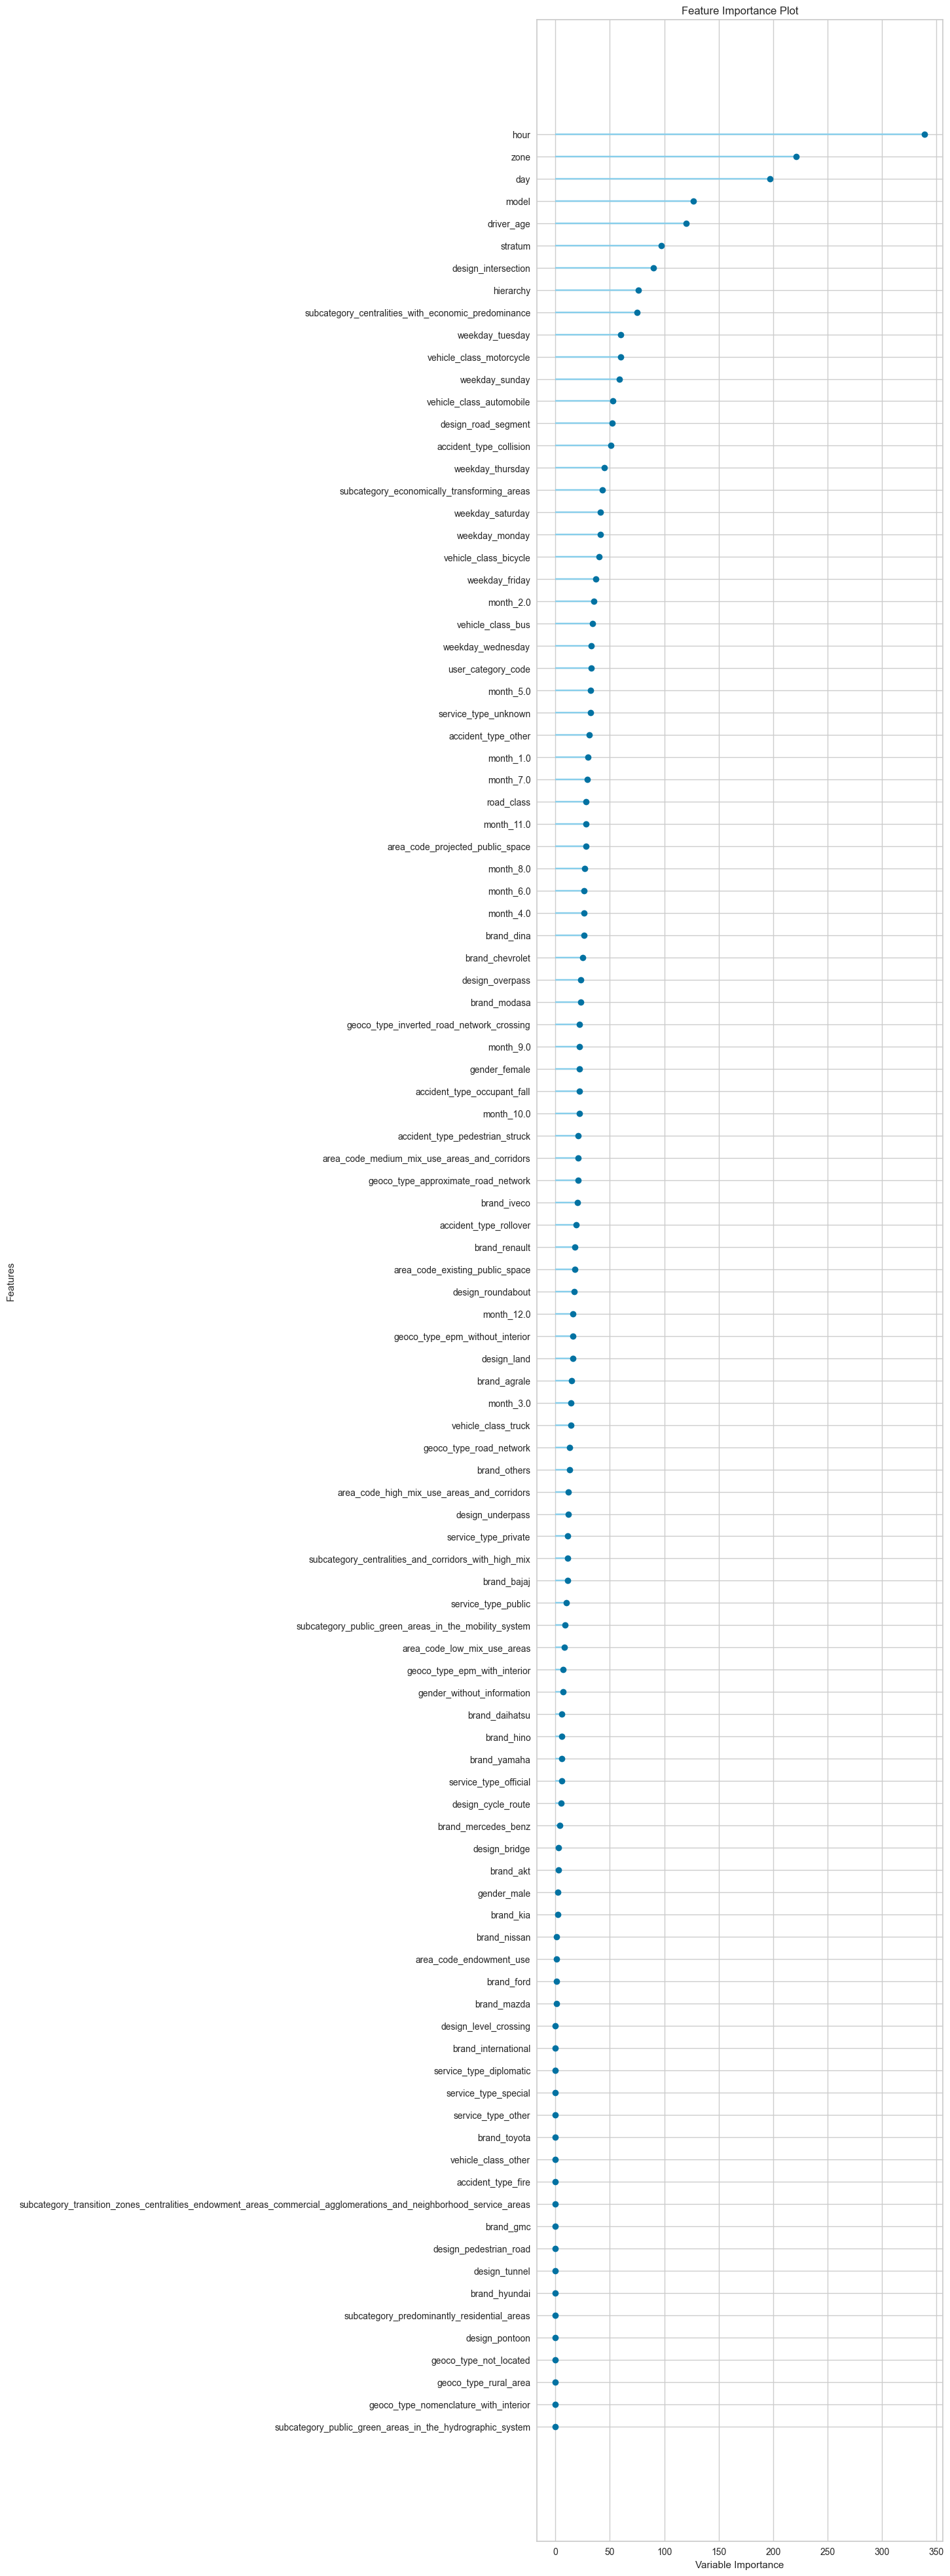

In [15]:
# Visualize feature importance
plot_model(best, plot="feature_all")